# ใบงานที่ 2: Data Preprocessing
### วิชา Machine Learning
**Dataset:** Student Study Habits & Exam Performance (สร้างขึ้นเองแบบ synthetic เพื่อจำลองปัญหาข้อมูลจริง)

ใบงาน: Part 1 (Dataset Exploration), Part 2 (Data Visualization), Part 3 (Data Cleaning), Part 4 (Feature Engineering)

---

โน้ตบุ๊กนี้ใช้ dataset ที่สร้างขึ้นเอง (synthetic) จำลองข้อมูลนักเรียน 600+ คน พร้อมปัญหาที่ตั้งใจใส่ไว้ เช่น
missing values, ข้อมูลซ้ำ, ข้อมูลผิดปกติ (outliers) และข้อมูลไม่สอดคล้องกัน (inconsistent categorical text)
เพื่อให้ได้ฝึกกระบวนการ Data Preprocessing ครบทุกขั้นตอนตามใบงาน

ตรงนี้จะเป็นการดึงไลบรารีมาใช้ มีทั้ง pandas, numpy, matplotlib.pyplot, seaborn เป็นต้น

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

pd.set_option('display.max_columns', None)

---

ตรงนี้เพิ่มเข้ามาเพื่อรองรับการเขียนป้ายกำกับกราฟเป็นภาษาไทย โดยดาวน์โหลดฟอนต์ Thai มาใช้

In [2]:
import matplotlib.font_manager as fm
import urllib.request

url = "https://github.com/google/fonts/raw/main/ofl/notosansthai/NotoSansThai%5Bwdth%2Cwght%5D.ttf"
font_path = "NotoSansThai.ttf"
urllib.request.urlretrieve(url, font_path)

fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()

---

## การสร้างชุดข้อมูล (Synthetic Dataset Generation)

สร้างชุดข้อมูลขึ้น เพื่อจำลองข้อมูลนักเรียน 600 คน ประกอบด้วยตัวแปร
`study_hours_per_week`, `attendance_rate`, `sleep_hours`, `parental_education`, `study_method` และ `exam_score`
โดยตั้งใจใส่ปัญหาคุณภาพข้อมูลลงไป ได้แก่ missing values, ข้อมูลซ้ำ, outliers และข้อความไม่สอดคล้องกัน
เพื่อให้มีของจริงให้ฝึกทำความสะอาดในขั้นตอนถัดไป

In [3]:
np.random.seed(42)
n = 600

study_methods = ["Self-study", "Group Study", "Tutoring", "Online Course"]
parent_edu_clean = ["High School", "Bachelor", "Master", "PhD"]

study_hours = np.round(np.random.normal(12, 5, n), 1).clip(0, None)
attendance_rate = np.round(np.random.normal(85, 10, n), 1).clip(0, 100)
sleep_hours = np.round(np.random.normal(6.5, 1.3, n), 1).clip(0, None)

exam_score = (
    15
    + study_hours * 1.3
    + attendance_rate * 0.3
    + sleep_hours * 1.0
    + np.random.normal(0, 11, n)
)
exam_score = np.round(exam_score, 1).clip(0, 100)

study_method = np.random.choice(study_methods, size=n, p=[0.35, 0.25, 0.2, 0.2])
parent_edu = np.random.choice(parent_edu_clean, size=n, p=[0.3, 0.4, 0.2, 0.1])
student_id = [f"STU{1000+i}" for i in range(n)]

df = pd.DataFrame({
    "student_id": student_id,
    "study_hours_per_week": study_hours,
    "attendance_rate": attendance_rate,
    "sleep_hours": sleep_hours,
    "parental_education": parent_edu,
    "study_method": study_method,
    "exam_score": exam_score,
})

# --- ใส่ missing values ---
miss_idx1 = np.random.choice(df.index, size=int(n*0.04), replace=False)
df.loc[miss_idx1, "study_hours_per_week"] = np.nan
miss_idx2 = np.random.choice(df.index, size=int(n*0.03), replace=False)
df.loc[miss_idx2, "sleep_hours"] = np.nan
miss_idx3 = np.random.choice(df.index, size=int(n*0.02), replace=False)
df.loc[miss_idx3, "attendance_rate"] = np.nan

# --- ใส่ข้อความไม่สอดคล้องกัน (inconsistent categorical) ---
inconsistent_idx = np.random.choice(df.index, size=int(n*0.15), replace=False)
def messify(v):
    choice = np.random.randint(0, 4)
    if v == "Bachelor":
        return ["bachelor", "Bachelors", "BACHELOR", "Bachelor "][choice]
    if v == "High School":
        return ["high school", "highschool", "High school ", "HIGH SCHOOL"][choice]
    if v == "Master":
        return ["master", "Masters", "MASTER", "Master "][choice]
    return ["phd", "PhD ", "Ph.D", "PHD"][choice]
for idx in inconsistent_idx:
    df.loc[idx, "parental_education"] = messify(df.loc[idx, "parental_education"])

# --- ใส่ outliers ---
outlier_idx = np.random.choice(df.index, size=6, replace=False)
df.loc[outlier_idx, "study_hours_per_week"] = np.random.uniform(70, 95, size=6).round(1)

outlier_idx2 = np.random.choice(df.index, size=4, replace=False)
df.loc[outlier_idx2, "attendance_rate"] = np.random.uniform(150, 180, size=4).round(1)

# --- ใส่ duplicate rows ---
dup_rows = df.sample(12, random_state=1)
df = pd.concat([df, dup_rows], ignore_index=True)

df = df.sample(frac=1, random_state=7).reset_index(drop=True)
df.to_csv("dataset.csv", index=False)
print("บันทึกไฟล์ dataset.csv เรียบร้อยแล้ว")

บันทึกไฟล์ dataset.csv เรียบร้อยแล้ว


> **--------------------------------------------------------------------------------**
>
> ## **Part 1: Dataset Exploration **


### 1.1 Load Dataset

ขั้นตอนนี้เป็นการโหลดชุดข้อมูลที่สร้างขึ้นเองเข้าสู่โปรแกรมด้วยไลบรารี Pandas เพื่อเตรียมสำหรับการสำรวจข้อมูลในขั้นตอนถัดไป

In [4]:
df = pd.read_csv('dataset.csv')
df.head()

,student_id,study_hours_per_week,attendance_rate,sleep_hours,parental_education,study_method,exam_score
0,STU1292,9.1,95.7,NaN,High School,Self-study,68.2
1,STU1515,15.8,88.6,6.4,PhD,Group Study,73.2
2,STU1404,9.7,92.0,5.9,High School,Self-study,50.6
3,STU1328,NaN,100.0,5.9,Master,Self-study,78.4
4,STU1217,10.8,93.9,6.8,Master,Group Study,42.0


### 1.2 Display Shape

ตรวจสอบขนาดของชุดข้อมูล (จำนวนแถวและคอลัมน์) เพื่อดูภาพรวมก่อนเริ่มกระบวนการวิเคราะห์

In [5]:
print(f"จำนวนแถว (rows): {df.shape[0]:,}")
print(f"จำนวนคอลัมน์ (columns): {df.shape[1]}")

จำนวนแถว (rows): 612
จำนวนคอลัมน์ (columns): 7


มีชุดข้อมูลจำนวน 612 แถว และมี 7 คอลัมน์ (มีแถวซ้ำที่ตั้งใจใส่ไว้รวมอยู่ด้วย)

---

### 1.3 Display Data Types

ตรวจสอบชนิดข้อมูล (Data Types) ของแต่ละคอลัมน์

In [6]:
df.dtypes.to_frame(name='dtype')

,dtype
student_id,str
study_hours_per_week,float64
attendance_rate,float64
sleep_hours,float64
parental_education,str
study_method,str
exam_score,float64


ข้อมูลตัวเลข (float64) จำนวน 4 คอลัมน์ ได้แก่ study_hours_per_week, attendance_rate, sleep_hours, exam_score

ข้อมูลข้อความ (object) จำนวน 3 คอลัมน์ ได้แก่ student_id, parental_education, study_method

---

### 1.4 Display Summary Statistics

แสดงสถิติเบื้องต้น (Summary Statistics) ของชุดข้อมูล เพื่อสรุปข้อมูลสำคัญของแต่ละคอลัมน์

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,612,600,STU1404,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_week,588.0,NaN,NaN,NaN,12.601531,8.227062,0.0,8.5,12.1,15.2,85.1
attendance_rate,599.0,NaN,NaN,NaN,86.065275,11.410054,56.0,79.35,86.1,92.45,178.3
sleep_hours,594.0,NaN,NaN,NaN,6.577946,1.298683,2.7,5.7,6.5,7.4,10.7
parental_education,612,20,Bachelor,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,612,4,Self-study,221,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exam_score,612.0,NaN,NaN,NaN,62.609804,12.568444,21.6,54.8,62.55,70.625,100.0


จากสถิติเบื้องต้นพบว่า `attendance_rate` มีค่าสูงสุดเกิน 100% (มากถึงราว 180%) ซึ่งเป็นไปไม่ได้ในความเป็นจริง
บ่งชี้ว่ามี **outliers** อยู่ในข้อมูล เช่นเดียวกับ `study_hours_per_week` ที่มีค่าสูงสุดเกิน 90 ชั่วโมง/สัปดาห์
ซึ่งเกินขีดจำกัดที่สมเหตุสมผล (168 ชั่วโมงต่อสัปดาห์คือเต็มสัปดาห์ แต่ 90+ ชั่วโมงเพื่อการเรียนอย่างเดียวถือว่าผิดปกติ)

---

### 1.5 Display Missing Values

แสดงจำนวนและร้อยละของข้อมูลที่หายไปในแต่ละคอลัมน์

In [8]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct(%)
study_hours_per_week,24,3.92
sleep_hours,18,2.94
attendance_rate,13,2.12


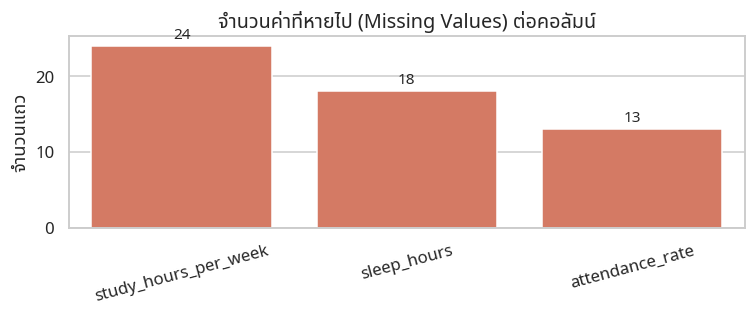

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_count'], ax=ax, color='#e76f51')
ax.set_title('จำนวนค่าที่หายไป (Missing Values) ต่อคอลัมน์', fontsize=13, fontweight='bold')
ax.set_ylabel('จำนวนแถว')
ax.set_xlabel('')
for i, v in enumerate(missing_summary['missing_count']):
    ax.text(i, v + 1, f'{v:,}', ha='center', fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

จากการตรวจสอบพบข้อมูลสูญหายใน 3 คอลัมน์ ได้แก่ study_hours_per_week, sleep_hours และ attendance_rate
ซึ่งเป็นสัดส่วนน้อย (2-4%) จึงสามารถจัดการได้ด้วยวิธีเติมข้อมูลในขั้นตอน Data Cleaning

---

### 1.6 Display Duplicate Records

ตรวจสอบข้อมูลซ้ำทั้งในระดับแถวข้อมูลและรหัสนักเรียน (student_id)

In [10]:
dup_count = df.duplicated().sum()
dup_id_count = df['student_id'].duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): {dup_count}")
print(f"จำนวน student_id ที่ซ้ำกัน: {dup_id_count}")

จำนวนแถวที่ซ้ำกันทั้งหมด (all columns): 12
จำนวน student_id ที่ซ้ำกัน: 12


ผลการตรวจสอบพบข้อมูลซ้ำ 12 แถว ตรงกับที่ตั้งใจใส่ไว้ตอนสร้างชุดข้อมูล จึงจำเป็นต้องลบออกในขั้นตอน Data Cleaning

---

### 1.7 Display Class Distribution

จัดกลุ่มระดับผลการเรียน (Performance Level) จากคะแนนสอบ (exam_score) เพื่อดูการกระจายตัวของกลุ่ม

In [11]:
def classify_performance(score):
    if score >= 80:
        return 'Distinction'
    elif score >= 50:
        return 'Pass'
    else:
        return 'Fail'

df['performance_level'] = df['exam_score'].apply(classify_performance)
class_dist = df['performance_level'].value_counts()
class_dist

performance_level
Pass           471
Fail            86
Distinction     55
Name: count, dtype: int64

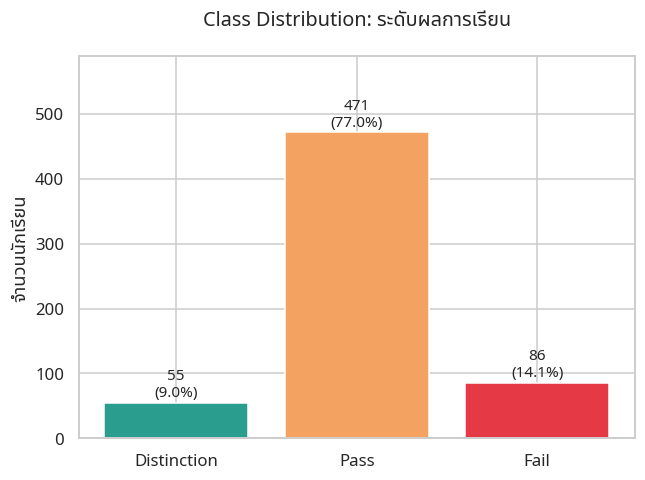

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
colors = ['#2a9d8f', '#f4a261', '#e63946']
order = ['Distinction', 'Pass', 'Fail']
values = [class_dist.get(c, 0) for c in order]
bars = ax.bar(order, values, color=colors)
ax.set_title('Class Distribution: ระดับผลการเรียน', fontsize=13, fontweight='bold', pad=20)
ax.set_ylabel('จำนวนนักเรียน')
ax.set_ylim(0, max(values) * 1.25)
for b in bars:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + max(values)*0.02, f'{h:,}\n({h/len(df)*100:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

จากการจำแนกระดับผลการเรียนพบว่านักเรียนส่วนใหญ่อยู่ในกลุ่ม **Pass** (ผ่านเกณฑ์ปกติ)
รองลงมาคือกลุ่ม **Fail** (ไม่ผ่านเกณฑ์) และมีนักเรียนส่วนน้อยที่สุดที่อยู่ในกลุ่ม **Distinction** (ผลการเรียนดีเยี่ยม)
สะท้อนให้เห็นว่าผลการเรียนของนักเรียนส่วนใหญ่กระจุกตัวอยู่ในระดับปานกลาง

---
---

## Part 2: Data Visualization

### 2.1 Histogram

โค้ดนี้แสดงการกระจายตัว (ความถี่) ของตัวแปรเชิงตัวเลขหลัก 3 ตัว ได้แก่ ชั่วโมงเรียน, ชั่วโมงนอน และคะแนนสอบ

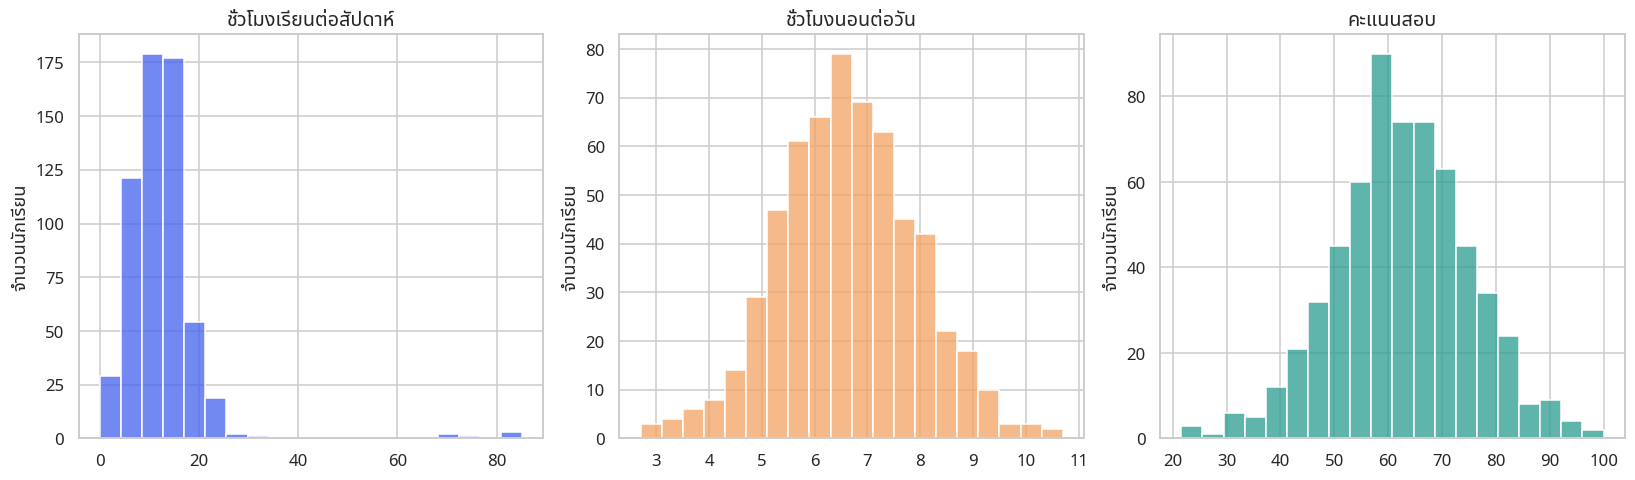

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ['ชั่วโมงเรียนต่อสัปดาห์', 'ชั่วโมงนอนต่อวัน', 'คะแนนสอบ']
cols = ['study_hours_per_week', 'sleep_hours', 'exam_score']
colors = ['#4361ee', '#f4a261', '#2a9d8f']

for ax, col, title, c in zip(axes, cols, titles, colors):
    sns.histplot(df[col].dropna(), bins=20, ax=ax, color=c, edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('จำนวนนักเรียน')

plt.tight_layout()
plt.show()

**ผลจากกราฟ 3 ช่องแรก**

ชั่วโมงเรียนต่อสัปดาห์: กระจายตัวแบบระฆังคว่ำ (normal-like) ส่วนใหญ่อยู่ราว 8-16 ชั่วโมง แต่มีบางจุดที่สูงผิดปกติ (outliers ที่ใส่ไว้)

ชั่วโมงนอน: ส่วนใหญ่อยู่ราว 5-8 ชั่วโมงต่อวัน

คะแนนสอบ: กระจายตัวคล้ายระฆังคว่ำเช่นกัน มีนักเรียนกลุ่มหนึ่งที่ทำคะแนนเต็ม 100 เนื่องจากค่าถูก clip ไว้ไม่ให้เกิน 100

---

โค้ดส่วนนี้เป็นการนำข้อมูลชั่วโมงเรียนมาเทียบกับคะแนนสอบ เพื่อดูแนวโน้มความสัมพันธ์

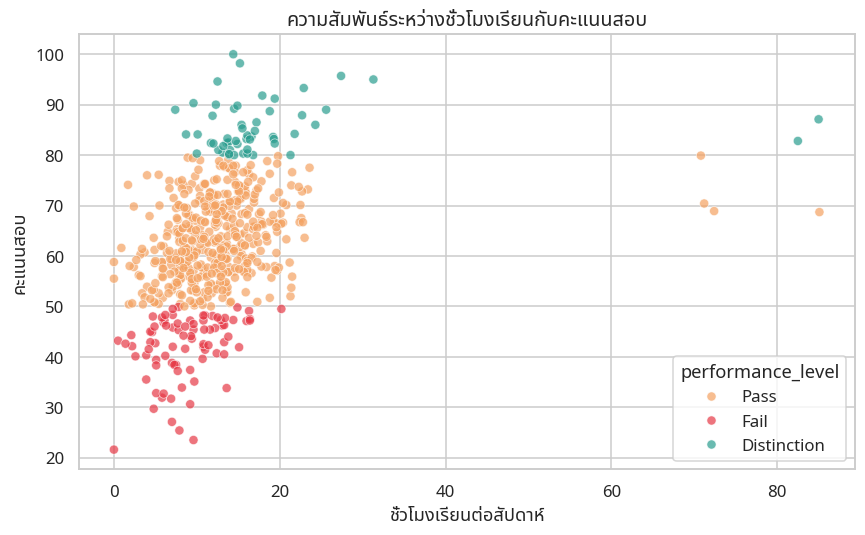

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='study_hours_per_week', y='exam_score', hue='performance_level',
                 palette={'Fail': '#e63946', 'Pass': '#f4a261', 'Distinction': '#2a9d8f'}, alpha=0.7, ax=ax)
ax.set_title('ความสัมพันธ์ระหว่างชั่วโมงเรียนกับคะแนนสอบ', fontsize=13, fontweight='bold')
ax.set_xlabel('ชั่วโมงเรียนต่อสัปดาห์')
ax.set_ylabel('คะแนนสอบ')
plt.tight_layout()
plt.show()

จากกราฟ scatter plot จะเห็นแนวโน้มว่ายิ่งใช้เวลาเรียนมากขึ้น คะแนนสอบก็มีแนวโน้มสูงขึ้นตามไปด้วย
แต่ก็มีจุดผิดปกติ (จุดที่ชั่วโมงเรียนสูงมากแต่คะแนนไม่ได้สูงตามสัดส่วน) ซึ่งคือ outliers ที่ใส่ไว้ในขั้นตอนสร้างข้อมูล

---

### 2.2 Correlation Heatmap

โค้ดส่วนนี้สร้าง Correlation Heatmap เพื่อดูว่าตัวแปรเชิงตัวเลขในชุดข้อมูลนี้มีความสัมพันธ์กันมากน้อยแค่ไหน

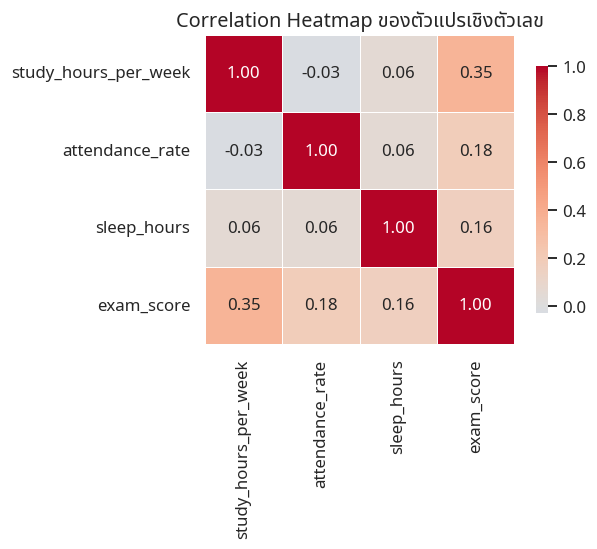

In [15]:
corr_cols = ['study_hours_per_week', 'attendance_rate', 'sleep_hours', 'exam_score']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlation Heatmap ของตัวแปรเชิงตัวเลข', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

heatmap แสดงว่า `study_hours_per_week`, `attendance_rate` และ `sleep_hours` ต่างมีความสัมพันธ์เชิงบวกกับ `exam_score`
ในระดับปานกลาง ซึ่งสอดคล้องกับวิธีสร้างข้อมูล (คะแนนสอบถูกกำหนดให้ขึ้นกับตัวแปรทั้งสามนี้บวก noise)
ส่วนตัวแปรอิสระด้วยกันเอง (study_hours, attendance, sleep) มีความสัมพันธ์กันค่อนข้างต่ำ ใกล้ 0

---
---

## Part 3: Data Cleaning

### 3.1 Missing Value Handling

โค้ดส่วนนี้จัดการกับค่าที่หายไป (Missing Values) ในคอลัมน์ตัวเลข โดยเติมด้วยค่ามัธยฐาน (median)
ของกลุ่มเดียวกัน (แยกตาม study_method) เพื่อให้สอดคล้องกับพฤติกรรมของแต่ละกลุ่ม

In [16]:
print("ก่อนแก้ไข - missing values:")
print(df[['study_hours_per_week', 'attendance_rate', 'sleep_hours']].isna().sum())

for col in ['study_hours_per_week', 'attendance_rate', 'sleep_hours']:
    df[col] = df.groupby('study_method')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

print("\nหลังแก้ไข - missing values:")
print(df[['study_hours_per_week', 'attendance_rate', 'sleep_hours']].isna().sum())

ก่อนแก้ไข - missing values:
study_hours_per_week    24
attendance_rate         13
sleep_hours             18
dtype: int64

หลังแก้ไข - missing values:
study_hours_per_week    0
attendance_rate         0
sleep_hours             0
dtype: int64


ก่อนแก้ไข: มีข้อมูลหายไปในทั้ง 3 คอลัมน์ตามที่ตั้งใจใส่ไว้ (2-4% ของข้อมูลทั้งหมด)

หลังแก้ไข: ใช้เทคนิคเติมค่ามัธยฐานแยกตามกลุ่มวิธีเรียน (study_method) ทำให้ค่าว่างลดลงเหลือ 0 ทุกคอลัมน์

---

### 3.2 Duplicate Removal

ลบข้อมูลที่ซ้ำซ้อนออกจากชุดข้อมูล เพื่อป้องกันไม่ให้นักเรียนคนเดิมถูกนับซ้ำ

In [21]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"จำนวนแถวก่อนลบซ้ำ: {before:,} | หลังลบซ้ำ: {after:,} | ลบไป: {before-after} แถว")

จำนวนแถวก่อนลบซ้ำ: 612 | หลังลบซ้ำ: 600 | ลบไป: 12 แถว


จะเห็นว่า `study_hours_per_week` และ `attendance_rate` มีค่า mean สูงกว่า median พอสมควร
เนื่องจากยังมี outliers (ชั่วโมงเรียนสูงเกินจริง และเปอร์เซ็นต์การเข้าเรียนเกิน 100%) ดึงค่าเฉลี่ยให้เบี่ยงเบนไป
จึงเลือกใช้ **Median** ในการเติมค่าที่หายไป เพราะทนทานต่อ outliers ได้ดีกว่า Mean

---

### 3.3 Incorrect Data Correction

โค้ดส่วนนี้แก้ไขข้อมูลข้อความที่ไม่สอดคล้องกัน (Inconsistent Data) ในคอลัมน์ `parental_education`
ซึ่งมีทั้งตัวพิมพ์เล็ก-ใหญ่ปะปนกัน มีช่องว่างเกิน และมีการสะกดต่างกัน (เช่น Bachelor, bachelor, BACHELOR, Bachelors)

In [18]:
print("ค่าที่พบก่อนแก้ไข:")
print(df['parental_education'].value_counts())

ค่าที่พบก่อนแก้ไข:
parental_education
Bachelor        226
High School     164
Master           87
PhD              44
bachelor         17
MASTER            8
High school       7
BACHELOR          7
Bachelors         6
HIGH SCHOOL       6
Bachelor          6
PhD               5
highschool        5
Masters           5
high school       5
master            4
PHD               4
Ph.D              2
phd               2
Master            2
Name: count, dtype: int64


In [19]:
def clean_education(v):
    v = str(v).strip().lower()
    if 'bachelor' in v:
        return 'Bachelor'
    if 'master' in v:
        return 'Master'
    if 'phd' in v or 'ph.d' in v:
        return 'PhD'
    if 'high' in v:
        return 'High School'
    return v.title()

df['parental_education'] = df['parental_education'].apply(clean_education)

print("ค่าที่ได้หลังแก้ไข:")
print(df['parental_education'].value_counts())

ค่าที่ได้หลังแก้ไข:
parental_education
Bachelor       262
High School    187
Master         106
PhD             57
Name: count, dtype: int64


หลังทำความสะอาดข้อความ พบว่าค่าทั้งหมดถูกรวมเหลือเพียง 4 หมวดหมู่ที่ถูกต้อง (High School, Bachelor, Master, PhD)
จากเดิมที่มีรูปแบบข้อความปะปนกันมากกว่า 10 แบบ

---

โค้ดส่วนนี้แก้ไขค่าผิดปกติ (Outliers) ในคอลัมน์ `attendance_rate` ที่มีค่าเกิน 100% ซึ่งเป็นไปไม่ได้ในความเป็นจริง
โดยจำกัดค่าสูงสุดไว้ที่ 100 และแก้ไข `study_hours_per_week` ที่สูงผิดปกติ (เกิน 60 ชั่วโมง/สัปดาห์) ด้วยค่ามัธยฐาน

In [20]:
print(f"attendance_rate เกิน 100: {(df['attendance_rate'] > 100).sum()} แถว")
print(f"study_hours_per_week เกิน 60: {(df['study_hours_per_week'] > 60).sum()} แถว")

df['attendance_rate'] = df['attendance_rate'].clip(upper=100)

study_median = df.loc[df['study_hours_per_week'] <= 60, 'study_hours_per_week'].median()
df.loc[df['study_hours_per_week'] > 60, 'study_hours_per_week'] = study_median

print(f"\nหลังแก้ไข - attendance_rate เกิน 100: {(df['attendance_rate'] > 100).sum()} แถว")
print(f"หลังแก้ไข - study_hours_per_week เกิน 60: {(df['study_hours_per_week'] > 60).sum()} แถว")

attendance_rate เกิน 100: 4 แถว
study_hours_per_week เกิน 60: 6 แถว

หลังแก้ไข - attendance_rate เกิน 100: 0 แถว
หลังแก้ไข - study_hours_per_week เกิน 60: 0 แถว


ผลลัพธ์แสดงว่าค่าผิดปกติทั้งสองจุดถูกแก้ไขจนไม่มีค่าเกินขอบเขตที่สมเหตุสมผลอีกต่อไป

---

ผลลัพธ์แสดงว่าลบแถวที่ซ้ำกันออกไปได้ 12 แถว ตรงกับจำนวนที่ตั้งใจใส่ไว้ตอนสร้างข้อมูล

---

### 3.4 Data Type Conversion

ตรวจสอบและแปลงชนิดข้อมูลให้เหมาะสม เช่น แปลง `parental_education` และ `study_method` ให้เป็นชนิด category
เพื่อประหยัดหน่วยความจำและเหมาะกับการนำไปใช้งานต่อ

In [22]:
df['parental_education'] = df['parental_education'].astype('category')
df['study_method'] = df['study_method'].astype('category')
df['performance_level'] = df['performance_level'].astype('category')

df.dtypes.to_frame(name='dtype')

,dtype
student_id,str
study_hours_per_week,float64
attendance_rate,float64
sleep_hours,float64
parental_education,category
study_method,category
exam_score,float64
performance_level,category


### 3.5 Compare Mean vs Median

ก่อนตัดสินใจว่าจะเติมข้อมูลด้วยค่าเฉลี่ย (Mean) หรือค่ามัธยฐาน (Median) ควรเปรียบเทียบทั้งสองค่าก่อน
เนื่องจาก outliers ที่มีอยู่ในข้อมูลอาจทำให้ Mean คลาดเคลื่อนได้มากกว่า Median

In [ ]:
compare = pd.DataFrame({
    'mean': df[['study_hours_per_week', 'attendance_rate', 'sleep_hours']].mean(),
    'median': df[['study_hours_per_week', 'attendance_rate', 'sleep_hours']].median()
})
compare

,mean,median
study_hours_per_week,12.571977,11.95
attendance_rate,86.063562,86.10
sleep_hours,6.576144,6.50


---
---

## Part 4: Feature Engineering

### 4.1 Label Encoding

เนื่องจาก `performance_level` เป็นตัวแปรที่มีลำดับ (ordinal) คือ Fail < Pass < Distinction
จึงใช้ Label Encoding แบบกำหนดลำดับเองเพื่อคงความหมายเชิงลำดับไว้

In [23]:
performance_order = {'Fail': 0, 'Pass': 1, 'Distinction': 2}
df['performance_encoded'] = df['performance_level'].map(performance_order)

df[['performance_level', 'performance_encoded']].drop_duplicates().sort_values('performance_encoded')

,performance_level,performance_encoded
38,Distinction,2
4,Fail,0
0,Pass,1


ตารางแสดงผลการจับคู่ (Mapping) เพื่อยืนยันความถูกต้อง

Fail (ไม่ผ่านเกณฑ์) แปลงเป็นเลข 0

Pass (ผ่านเกณฑ์) แปลงเป็นเลข 1

Distinction (ผลการเรียนดีเยี่ยม) แปลงเป็นเลข 2

---

### 4.2 One-Hot Encoding

ถัดมาเป็นการแปลงข้อมูลหมวดหมู่ที่ไม่มีลำดับ (nominal) ด้วยวิธี One-Hot Encoding กับคอลัมน์ `study_method`
เนื่องจากวิธีเรียนแต่ละแบบไม่มีลำดับความสำคัญที่ชัดเจนต่อกัน

In [24]:
method_ohe = pd.get_dummies(df['study_method'], prefix='method')
df_encoded = pd.concat([df, method_ohe], axis=1)

print("คอลัมน์ที่ได้จาก One-Hot Encoding:")
print(list(method_ohe.columns))
df_encoded[['study_method'] + list(method_ohe.columns)].head()

คอลัมน์ที่ได้จาก One-Hot Encoding:
['method_Group Study', 'method_Online Course', 'method_Self-study', 'method_Tutoring']


,study_method,method_Group Study,method_Online Course,method_Self-study,method_Tutoring
0,Self-study,False,False,True,False
1,Group Study,True,False,False,False
2,Self-study,False,False,True,False
3,Self-study,False,False,True,False
4,Group Study,True,False,False,False


ผลลัพธ์แสดงว่าคอลัมน์ `study_method` ถูกแยกออกเป็น 4 คอลัมน์ย่อย ได้แก่ method_Self-study, method_Group Study,
method_Tutoring และ method_Online Course โดยแต่ละแถวจะมีค่า True เฉพาะคอลัมน์ที่ตรงกับวิธีเรียนของนักเรียนคนนั้น

---
---

## สรุป

- **LAB1**: สำรวจ dataset สังเคราะห์ขนาด 612 แถว, 7 คอลัมน์ พบ missing values ใน 3 คอลัมน์ตัวเลข, พบข้อมูลซ้ำ 12 แถว
  และจำแนกกลุ่มผลการเรียนออกเป็น Fail/Pass/Distinction
- **LAB2**: histogram แสดงการกระจายตัวของตัวแปรเชิงตัวเลข, scatter plot แสดงแนวโน้มบวกระหว่างชั่วโมงเรียนกับคะแนนสอบ,
  และ correlation heatmap แสดงความสัมพันธ์ระดับปานกลางระหว่างตัวแปรอิสระกับคะแนนสอบ
- **Part 3**: เติมค่า missing ด้วย median แยกตามกลุ่ม, แก้ไขข้อความไม่สอดคล้องกันในคอลัมน์ parental_education,
  แก้ไข outliers ในคอลัมน์ attendance_rate และ study_hours_per_week, ลบข้อมูลซ้ำ, และแปลงชนิดข้อมูลเป็น category
- **Part 4**: ใช้ Label Encoding แบบกำหนดลำดับกับตัวแปรที่มีลำดับ (performance_level)
  และ One-Hot Encoding กับตัวแปรไม่มีลำดับ (study_method)

### จัดทำโดย
นางสาวกชกร คมอาวุธ รหัสนักศึกษา 116710400236-1 กลุ่มเรียนที่ 2